# IEEE CIS Fraud Detection Pipeline


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plotMe
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from typing import Dict, List, Tuple

In [ ]:
import pandas
import numpy
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from typing import Dict, List, Tuple

In [ ]:
TRAIN_TRANS = pd.read_csv('/content/drive/MyDrive/Dataset/IEEE CIS Dataset/train_transaction.csv')
TRAIN_IDENT = pd.read_csv('/content/drive/MyDrive/Dataset/IEEE CIS Dataset/train_identity.csv')

In [ ]:
# Connecting two dataset
train_tr = TRAIN_TRANS.set_index("TransactionID")
train_id = TRAIN_IDENT.set_index("TransactionID")
mainData = train_tr.join(train_id, how="left")

In [ ]:
# Creating Index Column
mainData['transactionID'] = mainData.index

In [ ]:
def stratified_transaction_sampling(
    df: pd.DataFrame,
    target_col: str = "isFraud",
    *,
    normal_ratio: int = 5,          # keep 1 : normal_ratio (fraud : normal)
    time_col: str | None = None,     # e.g. "TransactionDT"
    time_quantile: float | None = None,  # e.g. 0.8 to keep earliest 80%
    random_state: int = 42,
) > pd.DataFrame:


    # 1. Optional temporal cutoff

    if time_col is not None and time_quantile is not None:
        t_cut = df[time_col].quantile(time_quantile)
        df = df[df[time_col] <= t_cut].copy()


    # 2. Separate positives / negatives

    fraud_df = df[df[target_col] == 1]
    normal_df = df[df[target_col] == 0]

    n_fraud = len(fraud_df)
    n_normal_keep = min(len(normal_df), n_fraud * normal_ratio)


    # 3. Subsample negatives

    normal_sampled = normal_df.sample(
        n=n_normal_keep,
        random_state=random_state
    )


    # 4. Combine & shuffle safely

    sampled_df = (
        pd.concat([fraud_df, normal_sampled])
        .sample(frac=1.0, random_state=random_state)
        .reset_index(drop=True)
    )


    # 5. Logging (important for sanity)

    print("Stratified Sampling Summary")
    print("" * 40)
    print(f"Fraud kept      : {len(fraud_df)}")
    print(f"Normal kept     : {len(normal_sampled)}")
    print(f"Total samples   : {len(sampled_df)}")
    print(f"Fraud rate      : {sampled_df[target_col].mean():.4f}")

    return sampled_df

In [ ]:
sampledData = stratified_transaction_sampling(
    df = mainData,
    normal_ratio = 6,
    time_col = 'TransactionDT',
)

Stratified Sampling Summary
----------------------------------------
Fraud kept      : 20663
Normal kept     : 123978
Total samples   : 144641
Fraud rate      : 0.1429


In [ ]:
data = mainData.sort_values("TransactionDT").reset_index(drop=True)

n = len(data)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = data.iloc[:train_end]
validation   = data.iloc[train_end:val_end]
test  = data.iloc[val_end:]

In [ ]:
def smote_nc_oversample_train(
    train_df: pd.DataFrame,
    target_col: str = "isFraud",
    categorical_cols: list = None,
    random_state: int = 42,
    sampling_strategy="auto"
):

    if categorical_cols is None:
        categorical_cols = []

    X = train_df.drop(columns=[target_col])
    y = train_df[target_col]

    # indices of categorical columns
    cat_indices = [X.columns.get_loc(col) for col in categorical_cols]

    smote = SMOTENC(
        categorical_features=cat_indices,
        sampling_strategy=sampling_strategy,
        random_state=random_state
    )

    X_resampled, y_resampled = smote.fit_resample(X, y)

    train_resampled = pd.concat(
        [pd.DataFrame(X_resampled, columns=X.columns),
         pd.Series(y_resampled, name=target_col)],
        axis=1
    )

    return train_resampled

In [ ]:
train = stratified_transaction_sampling(
    df = train,
    normal_ratio = 12,
    time_col = 'TransactionDT',
)

Stratified Sampling Summary
----------------------------------------
Fraud kept      : 14538
Normal kept     : 174456
Total samples   : 188994
Fraud rate      : 0.0769


In [ ]:
len(test)

88581

In [ ]:
len(train)

188994

In [ ]:
# Identifying the non numeric columns
all_dtypes = mainData.dtypes

# Initializations
NON_NUMERIC_COLUMN = []
NUMERIC_COLUMNS = []

non_numeric_lookup = ['object', 'category', 'bool']

for columnName, dtypeInfo in all_dtypes.items():
  if dtypeInfo in non_numeric_lookup:
    NON_NUMERIC_COLUMN.append(columnName)
  else:
    NUMERIC_COLUMNS.append(columnName)

# Missing Value Handling

In [ ]:
# @title
# Missing Values Handling
def handle_nulls_tabular(
    *,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    categorical_cols: List[str],
    continuous_cols: List[str],
    cat_strategy: str = "most_frequent",
    cont_strategy: str = "mean",
) > Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict]:

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    imputation_metadata = {
        "categorical": {},
        "continuous": {}
    }


    # CATEGORICAL FEATURES

    for col in categorical_cols:
        if cat_strategy == "most_frequent":
            fill_value = train_df[col].mode(dropna=True)[0]
        elif cat_strategy == "constant":
            fill_value = "__MISSING__"
        else:
            raise ValueError("cat_strategy must be 'most_frequent' or 'constant'")

        train_df[col] = train_df[col].fillna(fill_value)
        val_df[col] = val_df[col].fillna(fill_value)
        test_df[col] = test_df[col].fillna(fill_value)

        imputation_metadata["categorical"][col] = fill_value


    # CONTINUOUS FEATURES

    for col in continuous_cols:
        if cont_strategy == "mean":
            fill_value = train_df[col].mean()
        elif cont_strategy == "median":
            fill_value = train_df[col].median()
        elif cont_strategy == "zero":
            fill_value = 0.0
        else:
            raise ValueError("cont_strategy must be 'mean', 'median', or 'zero'")

        train_df[col] = train_df[col].fillna(fill_value)
        val_df[col] = val_df[col].fillna(fill_value)
        test_df[col] = test_df[col].fillna(fill_value)

        imputation_metadata["continuous"][col] = fill_value

    return train_df, val_df, test_df, imputation_metadata

In [ ]:
len(train)

188994

In [ ]:
trainData, validationData, testData, metaData = handle_nulls_tabular(
    train_df = train,
    val_df = validation,
    test_df = test,
    categorical_cols = NON_NUMERIC_COLUMN,
    continuous_cols = NUMERIC_COLUMNS
)

In [ ]:
trainData['TransactionDT']

,TransactionDT
0,654557
1,9392210
2,4988769
3,497777
4,1883106
...,...
188989,1282800
188990,3193094
188991,10170299
188992,5967334


# Feature Importance Dataset

In [ ]:
featureImportance = pd.read_csv(r'/content/drive/MyDrive/Dataset/featureImportance/IEEE_feature_importance/importance.csv')

In [ ]:
featureImportance.loc[featureImportance['importance_mean'] > 0].head(300)

,feature,importance_mean,importance_std
0,C1,0.026067,1.020116e-03
1,C11,0.009552,6.031036e-04
2,C2,0.008633,4.998867e-04
3,card6,0.008473,5.731723e-04
4,TransactionAmt,0.007548,7.475048e-04
...,...,...,...
295,V216,0.000003,3.794679e-05
296,id_25,0.000002,1.931859e-06
297,V170,0.000002,3.817782e-05
298,V177,0.000001,1.877818e-05


Features Picker Function

In [ ]:
def apply_stable_feature_selection(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    importance_df: pd.DataFrame,
    target_col: str,
    mean_col: str,
    std_col: str,
    feature_col: str = "feature",
    threshold: float = 0.90,
    plot: bool = True
):

    df = importance_df.copy()


    # 1. Stability filter

    df["stability_score"] = df[mean_col]  df[std_col]
    df = df[df["stability_score"] > 0]
    df = df[df[mean_col] > 0]

    if len(df) == 0:
        raise ValueError("No features passed stability filtering (mean  std > 0).")


    # 2. Sort and compute cumulative importance

    df = df.sort_values(mean_col, ascending=False).reset_index(drop=True)

    df["cumulative_importance"] = df[mean_col].cumsum()
    total_importance = df[mean_col].sum()
    df["cumulative_ratio"] = df["cumulative_importance"] / total_importance


    # 3. Find cutoff

    cutoff_idx = df[df["cumulative_ratio"] >= threshold].index[0]
    selected_df = df.loc[:cutoff_idx]
    selected_features = selected_df[feature_col].tolist()


    # 4. Apply to datasets (NO reshuffle)

    keep_cols = selected_features + [target_col] + ['transactionID', 'TransactionDT']

    train_filtered = train_df[keep_cols].copy()
    val_filtered   = val_df[keep_cols].copy()
    test_filtered  = test_df[keep_cols].copy()


    # 5. Plot: Horizontal bar chart like your example

    if plot:
        top_n = min(20, len(df))  # safely handle <20 features
        plot_df = df.head(top_n).copy()

        # dynamic height so all feature names fit
        fig_h = max(6, 0.35 * len(plot_df))
        plt.figure(figsize=(14, fig_h))

        # horizontal bar chart
        plt.barh(plot_df[feature_col].astype(str), plot_df[mean_col].values)

        # put most important at the top (like your image)
        plt.gca().invert_yaxis()

        plt.xlabel("Importance Score")
        plt.ylabel("")  # cleaner like the example
        plt.title("Feature Importance (Permutation Importance)")

        plt.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()


    # 6. Metadata

    meta = {
        "num_original_features": importance_df.shape[0],
        "num_selected_features": len(selected_features),
        "importance_threshold": threshold,
        "cutoff_index": cutoff_idx,
        "selected_features": selected_features,
        "importance_table": selected_df
    }

    return train_filtered, val_filtered, test_filtered, meta

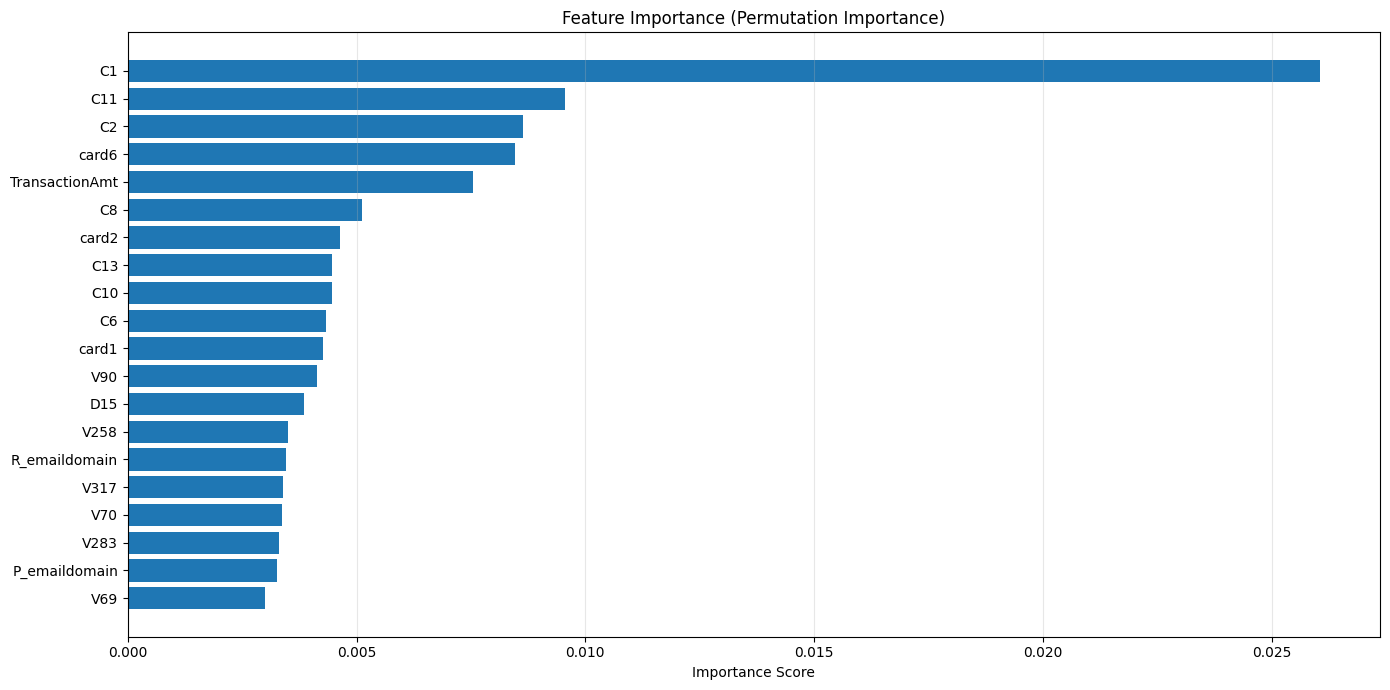

In [ ]:
finalTrainSet, finalValidationSet, finalTestSet, metas = apply_stable_feature_selection(
    train_df = trainData,
    val_df = validationData,
    test_df = testData,
    importance_df = featureImportance,
    target_col = 'isFraud',
    mean_col = 'importance_mean',
    std_col = 'importance_std',
)

In [ ]:
numbers = [1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
firstValue = 'C'
finalColumn = []

for secondLetter in numbers:
  finalname = (firstValue + str(secondLetter))

  finalColumn.append(finalname)

# Adding M columns too
Mcolumns = ['M3', 'M4', 'M5', 'M6']
finalColumn = finalColumn + Mcolumns

# Adding Card Columns too
cardColumns = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
finalColumn = finalColumn + cardColumns

# Checking Vs
vColumns = []
for columns in finalTrainSet.columns:
  checking = columns.startswith('V')
  if checking:
    vColumns.append(columns)

finalColumn = vColumns + finalColumn

ids = ['id_02', 'id_05', 'id_06', 'id_19', 'id_30', 'id_31']
finalColumn = finalColumn + ids

In [ ]:
categorical_cols_for_smote = finalTrainSet.select_dtypes(include=['object', 'category']).columns.tolist()
finalTrainSet = smote_nc_oversample_train(
    train_df = finalTrainSet,
    categorical_cols = categorical_cols_for_smote
)

In [ ]:
finalTrainSet.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/rawtrain.csv')
finalValidationSet.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/rawvalidation.csv')
finalTestSet.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/rawtest.csv')

# GNNspecific pipeline for the model

In [ ]:
def prepare_hetero_feature_pipeline(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str = "isFraud",
    tx_id_col: str = "TransactionID",
    node_columns=None,
    onehot_unique_threshold: int = 5,
    ordinal_unique_threshold: int = 50,
):

    if node_columns is None:
        # Removing card3, card5, p_emaildomain, R_emaildomain, id_30
        node_columns = [
            "card1", "card2",
            "addr1",
            "DeviceInfo",
            "id_31",
        ]

    #  basic checks
    for name, df in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"{name} must be a pandas DataFrame.")
        for col in [tx_id_col, target_col]:
            if col not in df.columns:
                raise ValueError(f"{name} is missing required column: {col}")

    # Keep only columns present across all splits (prevents silent schema mismatch)
    common_cols = list(set(train_df.columns) & set(val_df.columns) & set(test_df.columns))
    train = train_df[common_cols].copy()
    val = val_df[common_cols].copy()
    test = test_df[common_cols].copy()

    # Ensure node columns exist if requested; if some missing, drop from node_columns
    node_columns = [c for c in node_columns if c in common_cols]

    #  transaction feature columns = everything except node cols + IDs + label
    excluded = set(node_columns + [tx_id_col, target_col])
    transaction_feature_columns = [c for c in common_cols if c not in excluded]

    # Workframes to hold engineered transaction features
    X_train = train[transaction_feature_columns].copy()
    X_val = val[transaction_feature_columns].copy()
    X_test = test[transaction_feature_columns].copy()

    # Identify categorical transaction features (object/category)
    cat_cols = [
        c for c in transaction_feature_columns
        if (pd.api.types.is_object_dtype(X_train[c]) or pd.api.types.is_categorical_dtype(X_train[c]))
    ]
    num_cols = [c for c in transaction_feature_columns if c not in cat_cols]

    #  encoding (fit on train only)
    nunique_train = {c: X_train[c].nunique(dropna=True) for c in cat_cols}
    ohe_cols = [c for c in cat_cols if nunique_train[c] <= onehot_unique_threshold]
    ord_cols = [c for c in cat_cols if onehot_unique_threshold < nunique_train[c] <= ordinal_unique_threshold]
    freq_cols = [c for c in cat_cols if nunique_train[c] > ordinal_unique_threshold]

    def _fill_cat(df_: pd.DataFrame, cols):
        if not cols:
            return df_
        df_[cols] = df_[cols].astype("object").where(df_[cols].notna(), "__MISSING__")
        return df_

    X_train = _fill_cat(X_train, cat_cols)
    X_val = _fill_cat(X_val, cat_cols)
    X_test = _fill_cat(X_test, cat_cols)

    artifacts = {}

    # 1) Onehot
    if ohe_cols:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        ohe_train = ohe.fit_transform(X_train[ohe_cols])
        ohe_val = ohe.transform(X_val[ohe_cols])
        ohe_test = ohe.transform(X_test[ohe_cols])

        ohe_feature_names = ohe.get_feature_names_out(ohe_cols).tolist()

        ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
        ohe_val_df = pd.DataFrame(ohe_val, columns=ohe_feature_names, index=X_val.index)
        ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_feature_names, index=X_test.index)

        artifacts["onehot_encoder"] = ohe
        artifacts["onehot_cols"] = ohe_cols
        artifacts["onehot_feature_names"] = ohe_feature_names
    else:
        ohe_train_df = pd.DataFrame(index=X_train.index)
        ohe_val_df = pd.DataFrame(index=X_val.index)
        ohe_test_df = pd.DataFrame(index=X_test.index)

    # 2) Ordinal encoding (unknown > 1)
    if ord_cols:
        ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=1)
        ord_train = ord_enc.fit_transform(X_train[ord_cols])
        ord_val = ord_enc.transform(X_val[ord_cols])
        ord_test = ord_enc.transform(X_test[ord_cols])

        ord_feature_names = [f"{c}__ord" for c in ord_cols]
        ord_train_df = pd.DataFrame(ord_train, columns=ord_feature_names, index=X_train.index)
        ord_val_df = pd.DataFrame(ord_val, columns=ord_feature_names, index=X_val.index)
        ord_test_df = pd.DataFrame(ord_test, columns=ord_feature_names, index=X_test.index)

        artifacts["ordinal_encoder"] = ord_enc
        artifacts["ordinal_cols"] = ord_cols
        artifacts["ordinal_feature_names"] = ord_feature_names
    else:
        ord_train_df = pd.DataFrame(index=X_train.index)
        ord_val_df = pd.DataFrame(index=X_val.index)
        ord_test_df = pd.DataFrame(index=X_test.index)

    # 3) Frequency encoding (trainonly maps, unknown > 0.0)
    freq_maps = {}
    if freq_cols:
        for c in freq_cols:
            vc = X_train[c].value_counts(dropna=False)
            freq_maps[c] = (vc / vc.sum()).to_dict()

        def _freq_encode(df_: pd.DataFrame, cols):
            out = {}
            for c in cols:
                mp = freq_maps[c]
                out[f"{c}__freq"] = df_[c].map(mp).fillna(0.0).astype(float)
            return pd.DataFrame(out, index=df_.index)

        freq_train_df = _freq_encode(X_train, freq_cols)
        freq_val_df = _freq_encode(X_val, freq_cols)
        freq_test_df = _freq_encode(X_test, freq_cols)

        artifacts["freq_cols"] = freq_cols
        artifacts["freq_maps"] = freq_maps
    else:
        freq_train_df = pd.DataFrame(index=X_train.index)
        freq_val_df = pd.DataFrame(index=X_val.index)
        freq_test_df = pd.DataFrame(index=X_test.index)

    # Numeric transaction features (coerce safely)
    X_train_num = X_train[num_cols].apply(pd.to_numeric, errors="coerce")
    X_val_num = X_val[num_cols].apply(pd.to_numeric, errors="coerce")
    X_test_num = X_test[num_cols].apply(pd.to_numeric, errors="coerce")

    # Fill numeric missing using train medians (leakagefree)
    med = X_train_num.median(numeric_only=True)
    X_train_num = X_train_num.fillna(med)
    X_val_num = X_val_num.fillna(med)
    X_test_num = X_test_num.fillna(med)
    artifacts["numeric_medians"] = med.to_dict()

    # Assemble engineered transaction feature tables (UNSCALED at this point)
    feat_train = pd.concat([X_train_num, ord_train_df, freq_train_df, ohe_train_df], axis=1)
    feat_val = pd.concat([X_val_num, ord_val_df, freq_val_df, ohe_val_df], axis=1)
    feat_test = pd.concat([X_test_num, ord_test_df, freq_test_df, ohe_test_df], axis=1)


    #  NODE FEATURE ENGINEERING (NEW)
    # Apply AFTER encoding (OHE/ORD/FREQ) and BEFORE scaling.
    # Leakagefree: fit node stats on TRAIN ONLY, then apply to all nodes.

    # 1) Normalize missing node IDs
    def _fill_node_ids(df_: pd.DataFrame, cols):
      out = df_.copy()
      for c in cols:
          out[c] = out[c].astype("object").where(out[c].notna(), "__MISSING__")
      return out

    train_nodes = _fill_node_ids(train[[tx_id_col] + node_columns], node_columns)
    val_nodes   = _fill_node_ids(val[[tx_id_col] + node_columns], node_columns)
    test_nodes  = _fill_node_ids(test[[tx_id_col] + node_columns], node_columns)

      # 2) Allowed transactiononly numeric bases for entity stats
      #    (Keep this list intentionally SMALL and meaningful)
    ALLOWED_TX_NUMERIC_COLS = [
          "TransactionAmt",
          # Optional (only if you explicitly want them):
          # "TransactionDT",
      ]

    stat_base_cols = [c for c in ALLOWED_TX_NUMERIC_COLS if c in X_train_num.columns]

  # 3) TRAINonly node statistics builder (nonfragmenting)
    def _build_node_stats_strict(
        node_col: str,
        train_node_df: pd.DataFrame,
        train_feat_df: pd.DataFrame,
        base_cols: list,
    ) > pd.DataFrame:

        tmp = pd.concat(
            [train_node_df[[tx_id_col, node_col]], train_feat_df[base_cols]],
            axis=1
        )

        grp = tmp.groupby(node_col, dropna=False)

        blocks = {}

        # Structural stats
        txn_count = grp.size().astype(float)
        blocks[f"{node_col}_txn_count"] = txn_count
        blocks[f"{node_col}_degree"] = txn_count
        blocks[f"{node_col}_{tx_id_col}_nunique"] = grp[tx_id_col].nunique().astype(float)

        denom = float(len(train_feat_df)) if len(train_feat_df) else 1.0
        blocks[f"{node_col}_degree_centrality"] = txn_count / denom
        blocks[f"{node_col}_log1p_degree"] = np.log1p(txn_count)

        # Transactiononly behavioral stats
        for c in base_cols:
            s = grp[c]
            blocks[f"{node_col}_{c}_mean"] = s.mean()
            blocks[f"{node_col}_{c}_std"]  = s.std(ddof=0).fillna(0.0)
            blocks[f"{node_col}_{c}_min"]  = s.min()
            blocks[f"{node_col}_{c}_max"]  = s.max()

        out = pd.concat(blocks, axis=1)
        out.index.name = node_col
        return out.astype(float)

    # 4) Build node feature tables + ID maps
    node_feature_tables = {}
    node_feature_columns = {}
    node_id_maps = {}

    combined_nodes_only = pd.concat(
        [
            _fill_node_ids(train[node_columns], node_columns),
            _fill_node_ids(val[node_columns], node_columns),
            _fill_node_ids(test[node_columns], node_columns),
        ],
        axis=0,
        ignore_index=True,
    )

    for nc in node_columns:
        stats_train = _build_node_stats_strict(
            node_col=nc,
            train_node_df=train_nodes,
            train_feat_df=feat_train,
            base_cols=stat_base_cols,
        )

        all_ids = (
            combined_nodes_only[nc]
            .astype("object")
            .where(combined_nodes_only[nc].notna(), "__MISSING__")
            .unique()
            .tolist()
        )

        full = pd.DataFrame(index=pd.Index(all_ids, name=nc))
        full = full.join(stats_train, how="left")

        # Safe fills for unseen entities
        fill_defaults = {}
        for col in full.columns:
            if col.endswith(("_txn_count", "_degree", "_degree_centrality", "_log1p_degree", "_nunique")):
                fill_defaults[col] = 0.0
            elif col.endswith("_std"):
                fill_defaults[col] = 0.0
            else:
                fill_defaults[col] = float(stats_train[col].mean()) if col in stats_train else 0.0

        full = full.fillna(fill_defaults).astype(float)

        node_feature_tables[nc] = full
        node_feature_columns[nc] = full.columns.tolist()
        node_id_maps[nc] = {node_id: i for i, node_id in enumerate(full.index.tolist())}

        artifacts.setdefault("node_stats", {})[nc] = {
            "stat_base_cols": stat_base_cols,
            "num_train_nodes": int(stats_train.shape[0]),
            "num_all_nodes": int(full.shape[0]),
        }



    #  scaling (trainfit only), skip scaling binary onehot columns
    # (keeps your existing behavior for transaction x)


    binary_cols = []
    for c in feat_train.columns:
        vals = feat_train[c].dropna().unique()
        if len(vals) <= 2 and set(vals).issubset({0, 1}):
            binary_cols.append(c)

    scale_cols = [c for c in feat_train.columns if c not in binary_cols]
    scaler = StandardScaler()

    if scale_cols:
        feat_train_scaled = feat_train.copy()
        feat_val_scaled = feat_val.copy()
        feat_test_scaled = feat_test.copy()

        feat_train_scaled[scale_cols] = scaler.fit_transform(feat_train[scale_cols])
        feat_val_scaled[scale_cols] = scaler.transform(feat_val[scale_cols])
        feat_test_scaled[scale_cols] = scaler.transform(feat_test[scale_cols])

        artifacts["scaler"] = scaler
        artifacts["scaled_cols"] = scale_cols
        artifacts["binary_cols_unscaled"] = binary_cols
    else:
        feat_train_scaled, feat_val_scaled, feat_test_scaled = feat_train, feat_val, feat_test
        artifacts["scaler"] = None
        artifacts["scaled_cols"] = []
        artifacts["binary_cols_unscaled"] = binary_cols

    engineered_tx_feature_cols = feat_train_scaled.columns.tolist()

    #  rebuild split frames with untouched node ids + engineered tx features
    def _rebuild(df_orig: pd.DataFrame, feat_scaled: pd.DataFrame) > pd.DataFrame:
        out = df_orig[[tx_id_col, target_col] + node_columns].copy()
        out[f"{tx_id_col}_orig"] = out[tx_id_col]
        out = out.drop(columns=[tx_id_col])
        out = pd.concat([out, feat_scaled], axis=1)
        return out

    train_out = _rebuild(train, feat_train_scaled)
    val_out = _rebuild(val, feat_val_scaled)
    test_out = _rebuild(test, feat_test_scaled)

    #  combine + add txn_index + masks
    train_out["__split__"] = "train"
    val_out["__split__"] = "val"
    test_out["__split__"] = "test"

    combined = pd.concat([train_out, val_out, test_out], axis=0, ignore_index=True)
    combined.insert(0, "txn_index", np.arange(len(combined), dtype=np.int64))

    train_mask = (combined["__split__"].values == "train")
    val_mask = (combined["__split__"].values == "val")
    test_mask = (combined["__split__"].values == "test")

    return {
        'train': train_out,
        'val': val_out,
        'test': test_out,
        "data": combined,
        "node_columns": node_columns,
        "transaction_feature_columns": engineered_tx_feature_cols,
        "node_feature_tables": node_feature_tables,       # NEW
        "node_feature_columns": node_feature_columns,     # NEW
        "node_id_maps": node_id_maps,                     # NEW
        "masks": {
            "train_mask": train_mask,
            "val_mask": val_mask,
            "test_mask": test_mask,
        },
        "artifacts": artifacts,
    }

In [ ]:
pipeline_result = prepare_hetero_feature_pipeline(
    train_df = finalTrainSet,
    val_df = finalValidationSet,
    test_df = finalTestSet,
    tx_id_col = 'transactionID'
)

/tmp/ipykernel_37387/638150370.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if (pd.api.types.is_object_dtype(X_train[c]) or pd.api.types.is_categorical_dtype(X_train[c]))


In [ ]:
train = pipeline_result['train']
validation = pipeline_result['val']
test = pipeline_result['test']

In [ ]:
# Identify categorical columns
categorical_cols = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Categorical columns identified for encoding: {categorical_cols}")

encoders = {}

for col in categorical_cols:

    # Ensure string type for safety
    train[col] = train[col].astype(str)
    validation[col] = validation[col].astype(str)
    test[col] = test[col].astype(str)

    # Fit ONLY on train
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])

    encoders[col] = le

    # Create mapping dictionary for safe transform
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}

    # Apply safe mapping to validation and test
    validation[col] = validation[col].map(mapping).fillna(1).astype(int)
    test[col] = test[col].map(mapping).fillna(1).astype(int)

Categorical columns identified for encoding: ['DeviceInfo', 'id_31', '__split__']


In [ ]:
def train_evaluate_random_forest(
    train_df,
    val_df,
    test_df,
    target_col='isFraud',
    *,
    n_estimators: int = 200,
    max_depth: int | None = None,
    min_samples_leaf: int = 5,
    class_weight: str | dict = "balanced",
    random_state: int = 42,
    paper_mode: bool = False,          # NEW
    return_test_probs: bool = False    # NEW
):

    #
    # 0. Prepare X and y
    #
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]


    # 1. Model

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_jobs=1,
        class_weight=class_weight,
        random_state=random_state,
    )

    # 2. Fit

    rf.fit(X_train, y_train)


    # 3. Probability predictions

    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs   = rf.predict_proba(X_val)[:, 1]
    test_probs  = rf.predict_proba(X_test)[:, 1]


    # 4. Paperstyle metrics (thresholdfree)

    train_metrics = {
        "roc_auc": roc_auc_score(y_train, train_probs),
        "pr_auc": average_precision_score(y_train, train_probs),
    }

    val_metrics = {
        "roc_auc": roc_auc_score(y_val, val_probs),
        "pr_auc": average_precision_score(y_val, val_probs),
    }

    test_metrics = {
        "roc_auc": roc_auc_score(y_test, test_probs),
        "pr_auc": average_precision_score(y_test, test_probs),
    }


    # 5. Deploymentstyle metrics (optional)

    best_t = None
    test_preds = None # Initialize test_preds

    if not paper_mode:
        thresholds = numpy.linspace(0.01, 0.5, 100)
        best_t, best_f1 = 0.5, 0.0

        for t in thresholds:
            preds = (val_probs >= t).astype(int)
            f1 = f1_score(y_val, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        test_preds = (test_probs >= best_t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

        test_metrics.update({
            "accuracy": accuracy_score(y_test, test_preds),
            "precision": precision_score(y_test, test_preds, zero_division=0),
            "recall": recall_score(y_test, test_preds, zero_division=0),
            "f1": f1_score(y_test, test_preds, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        })


    # 6. Return

    out = {
        "model": rf,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "best_threshold": best_t,
    }

    if return_test_probs:
        out["test_probs"] = test_probs
        out["y_test"] = y_test.values

    # Add actual and predicted values dataframe
    if test_preds is not None:
        out['predictions_df'] = pandas.DataFrame({
            'randomforest_actual': y_test.values,
            'randomforest_predicted': test_preds,
            'randomforest_probs': test_probs
        })

    return out


def run_model_with_seeds_collect(
    train,
    validation,
    test,
    *,
    trainer_fn,
    seeds=[5, 17, 32],
    target_col="isFraud",
    verbose=True,
):

    def _extract_y_and_probs(res: dict):
        # Prefer explicit arrays if available
        if "test_probs" in res and "y_test" in res:
            y = np.asarray(res["y_test"]).astype(int).ravel()
            p = np.asarray(res["test_probs"]).astype(float).ravel()
            return y, p

        # Otherwise use predictions_df
        if "predictions_df" not in res:
            raise KeyError("Expected res to include ('test_probs','y_test') or 'predictions_df'.")

        df = res["predictions_df"]
        if target_col not in df.columns:
            raise KeyError(f"predictions_df missing target_col='{target_col}'.")

        # Heuristic: pick a prob/pred column
        prob_candidates = [c for c in df.columns if c != target_col and ("prob" in c.lower() or "pred" in c.lower())]
        if prob_candidates:
            prob_col = prob_candidates[0]
        else:
            numeric_cols = [c for c in df.columns if c != target_col and pd.api.types.is_numeric_dtype(df[c])]
            if not numeric_cols:
                raise KeyError("Could not find a probability column in predictions_df.")
            prob_col = numeric_cols[0]

        y = df[target_col].to_numpy(dtype=int).ravel()
        p = df[prob_col].to_numpy(dtype=float).ravel()
        return y, p

    all_metrics_rows = []
    pr_auc_rows = []
    probs_list = []
    y_ref = None

    for seed in seeds:
        if verbose:
            print(f"\n====== Running model with seed {seed} ======")

        res = trainer_fn(seed)

        #  metrics dict (whatever your trainer returns)
        metrics = res.get("test_metrics", {})
        trainmetrics = res.get("train_metrics", {})
        valmetrics = res.get("val_metrics", {})
        if verbose:
            print('train metric', trainmetrics)
            print('val metric', valmetrics)
            print("test_metrics:", metrics)

        #  extract y/probs and compute PRAUC consistently
        y_true, probs = _extract_y_and_probs(res)

        if y_ref is None:
            y_ref = y_true
        else:
            # ensure exact same test order across seeds
            if len(y_true) != len(y_ref) or not np.array_equal(y_true, y_ref):
                raise ValueError(
                    "y_true mismatch across seeds. Ensure the SAME test set order is used every run."
                )

        # PRAUC (Average Precision)
        pr_auc = average_precision_score(y_true, probs)

        # store all metrics + computed pr_auc + seed
        row = {"seed": seed, **metrics, "pr_auc": pr_auc}
        all_metrics_rows.append(row)

        pr_auc_rows.append({"seed": seed, "pr_auc": pr_auc})
        probs_list.append(probs)


    # DataFrames

    metrics_df = pd.DataFrame(all_metrics_rows)
    pr_auc_df = pd.DataFrame(pr_auc_rows)

    # averaged metrics (numeric only)
    avg_metrics = metrics_df.drop(columns=["seed"], errors="ignore").mean(numeric_only=True).to_dict()

    # averaged probs dataframe with actuals
    probs_mat = np.vstack(probs_list)  # (n_seeds, n_samples)
    avg_prob = probs_mat.mean(axis=0)

    avg_probs_df = pd.DataFrame({
        target_col: y_ref,
        "avg_prob": avg_prob
    })

    return avg_metrics, pr_auc_df, avg_probs_df, metrics_df

In [ ]:
pipeline_result['train'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/train.csv')
pipeline_result['val'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/validation.csv')
pipeline_result['test'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/IEEECIS/test.csv')

# Bank Marketing Pipeline

In [ ]:
bankData = pd.read_csv(r'/content/drive/MyDrive/Dataset/Bank Marketing/bankfull.csv', delimiter=';')

In [ ]:
bankData

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
bankData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
print(len(bankData.columns))

17


In [ ]:
print(
    bankData['y'].value_counts()
)

y
no     39922
yes     5289
Name: count, dtype: int64


# Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

def engineer_bank_marketing_features(df: pd.DataFrame) > pd.DataFrame:
    df = df.copy()

    # 2. AGE FEATURES

    df["age_bucket"] = pd.cut(
        df["age"],
        bins=[17, 29, 39, 49, 59, 100],
        labels=["young", "early_career", "mid_career", "senior", "retirement"]
    )
    df["is_senior"] = (df["age"] >= 60).astype(int)


    # 3. BALANCE FEATURES

    df["log_balance"] = np.log1p(df["balance"].clip(lower=0))
    df["balance_sign"] = np.sign(df["balance"]).map({1: "negative", 0: "zero", 1: "positive"})
    df["balance_bucket"] = pd.cut(
        df["balance"],
        bins=[np.inf, 0, 1000, 5000, np.inf],
        labels=["overdraft", "low", "medium", "high"]
    )


    # 4. TEMPORAL FEATURES

    month_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4,
        "may": 5, "jun": 6, "jul": 7, "aug": 8,
        "sep": 9, "oct": 10, "nov": 11, "dec": 12
    }
    df["month_num"] = df["month"].map(month_map)

    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["is_month_start"] = (df["day"] <= 7).astype(int)
    df["is_month_end"] = (df["day"] >= 25).astype(int)

    df["season"] = pd.cut(
        df["month_num"],
        bins=[0, 3, 6, 9, 12],
        labels=["Q1", "Q2", "Q3", "Q4"]
    )


    # 5. CONTACT RECENCY FEATURES

    df["was_contacted_before"] = (df["previous"] > 0).astype(int)
    df["is_recent_contact"] = ((df["pdays"] > 0) & (df["pdays"] <= 30)).astype(int)

    df["pdays_bucket"] = np.where(
        df["pdays"] == 1, "never",
        np.where(df["pdays"] <= 30, "recent",
                 np.where(df["pdays"] <= 180, "medium", "old"))
    )

    df["previous_contact_intensity"] = df["previous"] / (df["pdays"].clip(lower=0) + 1)


    # 6. CAMPAIGN INTENSITY

    df["campaign_bucket"] = np.where(
        df["campaign"] == 1, "first_contact",
        np.where(df["campaign"] <= 3, "moderate", "aggressive")
    )

    df["contact_fatigue_score"] = df["campaign"] * (df["previous"] + 1)
    df["over_contacted_flag"] = ((df["campaign"] >= 4) & (df["pdays"] <= 30)).astype(int)


    # 7. CALL EFFECTIVENESS

    df["log_duration"] = np.log1p(df["duration"])

    df["duration_bucket"] = pd.cut(
        df["duration"],
        bins=[1, 60, 180, 360, np.inf],
        labels=["very_short", "short", "medium", "long"]
    )

    df["high_engagement_call"] = (df["duration"] >= 300).astype(int)


    # 8. LOAN & RISK FEATURES

    df["has_any_loan"] = ((df["housing"] == "yes") | (df["loan"] == "yes")).astype(int)
    df["financial_stress_flag"] = ((df["has_any_loan"] == 1) & (df["balance"] < 0)).astype(int)

    df["default_risk_profile"] = (
        df["default"].astype(str) + "_" +
        df["housing"].astype(str) + "_" +
        df["loan"].astype(str)
    )


    # 9. SOCIOECONOMIC INTERACTIONS

    df["job_education_combo"] = df["job"] + "_" + df["education"]
    df["job_age_interaction"] = df["job"] + "_" + df["age_bucket"].astype(str)

    education_map = {"primary": 1, "secondary": 2, "tertiary": 3}
    df["education_level_ordinal"] = df["education"].map(education_map)


    # 10. CHANNEL & OUTCOME MEMORY

    df["contact_type_effective"] = df["contact"] + "_" + df["duration_bucket"].astype(str)
    df["contact_recency_channel"] = df["contact"] + "_" + df["pdays_bucket"].astype(str)

    df["successful_before"] = (df["poutcome"] == "success").astype(int)
    df["failure_then_retry"] = ((df["poutcome"] == "failure") & (df["campaign"] > 1)).astype(int)
    df["poutcome_campaign_combo"] = df["poutcome"] + "_" + df["campaign_bucket"]


    # 11. Drop helper columns

    df = df.drop(columns=["month_num"])

    return df


In [ ]:
engineered_data = engineer_bank_marketing_features(df = bankData)

In [ ]:
len(engineered_data.columns)

50

In [ ]:
def build_train_val_test_pipeline(
    df: pd.DataFrame,
    *,
    target_col: str,
    train_ratio: float = 0.65,
    random_state: int = 42,
):


    # 0. Defensive copy

    data = df.copy(deep=True)

    if target_col not in data.columns:
        raise KeyError(f"Target column '{target_col}' not found")


    # 1. Robust label conversion (no NaNs allowed)

    y_raw = data[target_col]

    if y_raw.dtype == "O":
        y = (
            y_raw.astype(str)
            .str.strip()
            .str.lower()
            .replace({"yes": 1, "no": 0})
        )
    else:
        y = y_raw

    y = pd.to_numeric(y, errors="coerce")

    if y.isna().any():
        raise ValueError(
            f"NaNs detected in target after mapping. "
            f"Unique values: {y_raw.unique()}"
        )

    data[target_col] = y.astype(int)


    # 2. Stratified TRAIN split

    sss_train = StratifiedShuffleSplit(
        n_splits=1,
        train_size=train_ratio,
        random_state=random_state,
    )

    train_idx, temp_idx = next(
        sss_train.split(data, data[target_col])
    )

    train_df = data.iloc[train_idx].reset_index(drop=True)
    temp_df  = data.iloc[temp_idx].reset_index(drop=True)


    # 3. Stratified VAL / TEST split (50 / 50)

    sss_val_test = StratifiedShuffleSplit(
        n_splits=1,
        train_size=0.5,
        random_state=random_state,
    )

    val_idx, test_idx = next(
        sss_val_test.split(temp_df, temp_df[target_col])
    )

    val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)


    # 4. Separate X / y

    X_train_raw = train_df.drop(columns=[target_col])
    X_val_raw   = val_df.drop(columns=[target_col])
    X_test_raw  = test_df.drop(columns=[target_col])

    y_train = train_df[target_col].values
    y_val   = val_df[target_col].values
    y_test  = test_df[target_col].values


    # 5. Identify feature types (trainonly)

    categorical_cols = X_train_raw.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numerical_cols = X_train_raw.select_dtypes(
        include=["int64", "float64", "bool"]
    ).columns.tolist()


    # 6. Preprocessing pipelines

    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )),
    ])

    num_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_pipeline, categorical_cols),
            ("num", num_pipeline, numerical_cols),
        ],
        remainder="drop",
    )


    # 7. Fit ONLY on train (no leakage)

    X_train = preprocessor.fit_transform(X_train_raw).toarray()
    X_val   = preprocessor.transform(X_val_raw).toarray()
    X_test  = preprocessor.transform(X_test_raw).toarray()

    feature_names = preprocessor.get_feature_names_out()


    # 8. Rebuild DataFrames

    train_final = pd.DataFrame(X_train, columns=feature_names)
    train_final[target_col] = y_train

    val_final = pd.DataFrame(X_val, columns=feature_names)
    val_final[target_col] = y_val

    test_final = pd.DataFrame(X_test, columns=feature_names)
    test_final[target_col] = y_test


    # 9. Final sanity checks

    assert train_final.shape[1] == len(feature_names) + 1
    assert not np.isnan(train_final[target_col]).any()

    return train_final, val_final, test_final, preprocessor, {
        'rawTrain': train_df,
        'rawVal': val_df,
        'rawTest': test_df
    }

In [ ]:
train, validation, test, preprocessor_fitted, raw_data = build_train_val_test_pipeline(
    df = engineered_data,
    target_col = 'y',
    train_ratio = 0.75
)

/tmp/ipython-input-567/487409073.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0})


In [ ]:
raw_data['rawTrain'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/tabTransData/train.csv')
raw_data['rawVal'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/tabTransData/val.csv')
raw_data['rawTest'].to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/tabTransData/test.csv')


In [ ]:
train.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/Bank Marketing/train.csv')
validation.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/Bank Marketing/validation.csv')
test.to_csv('/content/drive/MyDrive/Dataset/TrainValidationTest/Bank Marketing/test.csv')

In [ ]:
len(train.columns)

249